---

<div style="font-size:small;">

MIT License

Copyright (c) [2026] Felipe Meza-Obando

*Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software for educational purposes only. You must give author appropriate credit, provide a link to the license and source, and indicate if changes were made.*
</div>

---

# **Extracción de entidades y frases clave**
### Autor: ***Dr. Ing. Felipe Meza-Obando***

En este laboratorio se analizarán resúmenes de películas para identificar:

- personas;
- organizaciones;
- lugares;
- fechas;
- frases clave;
- palabras y expresiones frecuentes.

La solución local emplea:

- **spaCy** para reconocimiento de entidades;
- **scikit-learn** para n-gramas y frases clave;
- **pandas** para organizar los resultados;
- **Matplotlib, Plotly y WordCloud** para visualizar la información.

Además de ejecutar el código, la notebook explica qué significa cada resultado y comprueba automáticamente si la extracción obtenida es razonable.

## 0. Requisitos e instalación

Se recomienda **Python 3.11**.

### Instalación con Conda

```bash
conda create -n nlp-entities python=3.11 -y
conda activate nlp-entities
conda install -c conda-forge jupyterlab numpy pandas scikit-learn matplotlib plotly spacy wordcloud -y
jupyter lab
```

### Instalación con pip

```bash
pip install jupyterlab numpy pandas scikit-learn matplotlib plotly spacy wordcloud
```

Esta notebook usa un modelo local basado en reglas mediante `EntityRuler`, por lo que no es necesario descargar modelos adicionales de spaCy.

## 1. Importación de bibliotecas

Se cargan las herramientas necesarias y se verifica que el entorno esté preparado.

In [1]:
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import spacy

from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud

print("Python:", sys.version.split()[0])
print("spaCy:", spacy.__version__)
print("Entorno preparado correctamente.")

Python: 3.13.5
spaCy: 3.8.11
Entorno preparado correctamente.


## 2. Creación del conjunto de datos

Para que los resultados sean fáciles de interpretar, se utilizará un conjunto pequeño de resúmenes de películas creado para este laboratorio.

Cada resumen contiene entidades claramente reconocibles, como nombres de personas, ciudades, organizaciones y fechas. También se incluye una categoría de referencia para facilitar la interpretación posterior.

In [2]:
movies = [
    {
        "movie_id": 1,
        "title": "Mission to Mars",
        "genre": "Science Fiction",
        "plot": "In 2045, astronaut Elena Ruiz joins NASA on a mission from Houston to Mars. The Orion spacecraft carries the crew through a dangerous solar storm."
    },
    {
        "movie_id": 2,
        "title": "The Last Goal",
        "genre": "Sports",
        "plot": "Coach Daniel Brooks leads the London Lions to the 2022 European final in Paris. Striker Marco Silva scores the winning goal against Madrid United."
    },
    {
        "movie_id": 3,
        "title": "The Silent Virus",
        "genre": "Medical Drama",
        "plot": "Doctor Sarah Kim works at Mercy Hospital in Boston during the 2020 outbreak. She collaborates with the World Health Organization to identify a new virus."
    },
    {
        "movie_id": 4,
        "title": "Code Black",
        "genre": "Technology",
        "plot": "Cybersecurity expert Noah Chen discovers an attack against Quantum Systems in Seattle. In 2024, he works with the FBI to prevent a massive data breach."
    },
    {
        "movie_id": 5,
        "title": "Desert Treasure",
        "genre": "Adventure",
        "plot": "Archaeologist Maya Patel travels from Cairo to the Sahara Desert in 1998. She searches for a lost temple with the support of the Cairo Museum."
    },
    {
        "movie_id": 6,
        "title": "Ocean Rescue",
        "genre": "Adventure",
        "plot": "Captain Lucas Grant leads the Pacific Rescue Agency from San Diego. In 2019, the team searches for survivors after a storm near Hawaii."
    },
    {
        "movie_id": 7,
        "title": "The Quantum Door",
        "genre": "Science Fiction",
        "plot": "Physicist Anna Müller works at CERN in Geneva. In 2032, she opens a quantum portal that connects Switzerland with a distant planet."
    },
    {
        "movie_id": 8,
        "title": "Champions of Tokyo",
        "genre": "Sports",
        "plot": "Runner Aisha Johnson represents Team USA at the 2021 Olympic Games in Tokyo. Nike sponsors her training before the championship."
    },
    {
        "movie_id": 9,
        "title": "The Hidden Cure",
        "genre": "Medical Drama",
        "plot": "Researcher Miguel Torres develops a cancer treatment at Stanford University in California. Pfizer funds the clinical trial in 2023."
    },
    {
        "movie_id": 10,
        "title": "Digital City",
        "genre": "Technology",
        "plot": "Engineer Sofia Rossi designs an artificial intelligence platform for NovaTech in Milan. The system is deployed across Italy in 2025."
    },
    {
        "movie_id": 11,
        "title": "Northern Lights",
        "genre": "Drama",
        "plot": "Photographer Emma Wilson travels from Toronto to Iceland in 2018. She documents the northern lights for National Geographic."
    },
    {
        "movie_id": 12,
        "title": "The Diplomat",
        "genre": "Political Drama",
        "plot": "Ambassador James Carter represents the United Nations during peace negotiations in Vienna. The agreement is signed in 2016."
    }
]

data = pd.DataFrame(movies)
display(data.head())

assert len(data) == 12
assert {"movie_id", "title", "genre", "plot"}.issubset(data.columns)

print("VERIFICACIÓN SUPERADA: se cargaron 12 películas con la estructura esperada.")

,movie_id,title,genre,plot
0,1,Mission to Mars,Science Fiction,"In 2045, astronaut Elena Ruiz joins NASA on a ..."
1,2,The Last Goal,Sports,Coach Daniel Brooks leads the London Lions to ...
2,3,The Silent Virus,Medical Drama,Doctor Sarah Kim works at Mercy Hospital in Bo...
3,4,Code Black,Technology,Cybersecurity expert Noah Chen discovers an at...
4,5,Desert Treasure,Adventure,Archaeologist Maya Patel travels from Cairo to...


VERIFICACIÓN SUPERADA: se cargaron 12 películas con la estructura esperada.


### ¿Qué debemos observar?

Cada fila representa una película y contiene:

- identificador;
- título;
- género;
- resumen argumental.

Los nombres de personas, ciudades, organizaciones y años serán utilizados posteriormente para comprobar si la extracción funciona.

## 3. Exploración básica del texto

Antes de aplicar técnicas de NLP, se calcula la cantidad de palabras de cada resumen.

In [3]:
data["word_count"] = data["plot"].apply(lambda text: len(text.split()))

display(data[["title", "genre", "word_count"]])

print("Promedio de palabras:", round(data["word_count"].mean(), 2))
print("Mínimo:", data["word_count"].min())
print("Máximo:", data["word_count"].max())

,title,genre,word_count
0,Mission to Mars,Science Fiction,25
1,The Last Goal,Sports,24
2,The Silent Virus,Medical Drama,25
3,Code Black,Technology,25
4,Desert Treasure,Adventure,25
5,Ocean Rescue,Adventure,23
6,The Quantum Door,Science Fiction,22
7,Champions of Tokyo,Sports,20
8,The Hidden Cure,Medical Drama,19
9,Digital City,Technology,20


Promedio de palabras: 22.0
Mínimo: 18
Máximo: 25


**Interpretación:** los resúmenes son breves y de longitud parecida. Esto evita que una película domine los resultados únicamente por tener mucho más texto.

## 4. Normalización del texto

La normalización elimina espacios repetidos y conserva una versión limpia para el análisis. No se eliminan mayúsculas en esta etapa porque ayudan a reconocer nombres propios.

In [ ]:
# Define una función para limpiar y normalizar cada resumen de película.
def normalize_text(text):
    
    # Elimina etiquetas HTML, por ejemplo: <p>, <br> o <div>.
    text = re.sub(r"<[^>]+>", " ", str(text))
    
    # Elimina direcciones web que comienzan con http o https.
    text = re.sub(r"https?://\S+", " ", text)
    
    # Sustituye espacios, saltos de línea o tabulaciones repetidas
    # por un único espacio.
    text = re.sub(r"\s+", " ", text)
    
    # Elimina espacios sobrantes al inicio y al final del texto.
    return text.strip()


# Aplica la función de limpieza a todos los resúmenes de la columna "plot"
# y guarda el resultado en una nueva columna llamada "clean_plot".
data["clean_plot"] = data["plot"].apply(normalize_text)

display(data[["title", "clean_plot"]].head())

assert data["clean_plot"].str.len().min() > 0
print("VERIFICACIÓN SUPERADA: no quedaron textos vacíos.")

## 5. Configuración del reconocimiento de entidades

Una entidad es un elemento con identidad propia dentro del texto. En este laboratorio se buscarán:

- `PERSON`: personas;
- `ORG`: organizaciones;
- `GPE`: países y ciudades;
- `DATE`: fechas o años.

Se utiliza `EntityRuler`, una herramienta de spaCy que reconoce patrones definidos previamente. Esta alternativa es local, transparente y apropiada para comprender cómo funciona la extracción.

In [5]:
nlp = spacy.blank("en")
ruler = nlp.add_pipe("entity_ruler")

people = [
    "Elena Ruiz", "Daniel Brooks", "Marco Silva", "Sarah Kim",
    "Noah Chen", "Maya Patel", "Lucas Grant", "Anna Müller",
    "Aisha Johnson", "Miguel Torres", "Sofia Rossi",
    "Emma Wilson", "James Carter"
]

organizations = [
    "NASA", "London Lions", "Madrid United", "Mercy Hospital",
    "World Health Organization", "Quantum Systems", "FBI",
    "Cairo Museum", "Pacific Rescue Agency", "CERN",
    "Team USA", "Nike", "Stanford University", "Pfizer",
    "NovaTech", "National Geographic", "United Nations"
]

places = [
    "Houston", "Mars", "London", "Paris", "Boston", "Seattle",
    "Cairo", "Sahara Desert", "San Diego", "Hawaii", "Geneva",
    "Switzerland", "Tokyo", "California", "Milan", "Italy",
    "Toronto", "Iceland", "Vienna"
]

patterns = []
patterns += [{"label": "PERSON", "pattern": value} for value in people]
patterns += [{"label": "ORG", "pattern": value} for value in organizations]
patterns += [{"label": "GPE", "pattern": value} for value in places]
patterns += [{"label": "DATE", "pattern": [{"TEXT": {"REGEX": r"^(19|20)\d{2}$"}}]}]

ruler.add_patterns(patterns)

print("Número de patrones definidos:", len(patterns))

Número de patrones definidos: 50


### ¿Qué está ocurriendo?

El modelo revisará cada resumen y marcará cualquier fragmento que coincida con los patrones. El proceso es similar a construir un pequeño diccionario especializado para el dominio de películas.

## 6. Extracción de entidades

Se procesa cada resumen y se guarda cada entidad junto con su tipo.

In [6]:
entity_rows = []

for _, row in data.iterrows():
    doc = nlp(row["clean_plot"])

    for entity in doc.ents:
        entity_rows.append({
            "movie_id": row["movie_id"],
            "title": row["title"],
            "genre": row["genre"],
            "entity": entity.text,
            "entity_type": entity.label_
        })

entities = pd.DataFrame(entity_rows)
display(entities.head(15))

print("Entidades extraídas:", len(entities))
assert len(entities) > 30

print("VERIFICACIÓN SUPERADA: se detectó una cantidad suficiente de entidades.")

,movie_id,title,genre,entity,entity_type
0,1,Mission to Mars,Science Fiction,2045,DATE
1,1,Mission to Mars,Science Fiction,Elena Ruiz,PERSON
2,1,Mission to Mars,Science Fiction,NASA,ORG
3,1,Mission to Mars,Science Fiction,Houston,GPE
4,1,Mission to Mars,Science Fiction,Mars,GPE
5,2,The Last Goal,Sports,Daniel Brooks,PERSON
6,2,The Last Goal,Sports,London Lions,ORG
7,2,The Last Goal,Sports,2022,DATE
8,2,The Last Goal,Sports,Paris,GPE
9,2,The Last Goal,Sports,Marco Silva,PERSON


Entidades extraídas: 60
VERIFICACIÓN SUPERADA: se detectó una cantidad suficiente de entidades.


### ¿Cómo saber si el resultado es correcto?

Las primeras filas deberían mostrar nombres como `Elena Ruiz`, `NASA`, `Houston`, `Mars` y `2045`, con tipos coherentes.

Un resultado sería dudoso si:

- no aparecen entidades;
- una persona se clasifica como lugar;
- una ciudad se clasifica como organización;
- los años no se reconocen como fechas.

## 7. Cantidad de entidades por tipo

Esta tabla resume cuántas personas, organizaciones, lugares y fechas fueron identificados.

,entity_type,count
0,GPE,18
1,ORG,17
2,PERSON,13
3,DATE,12


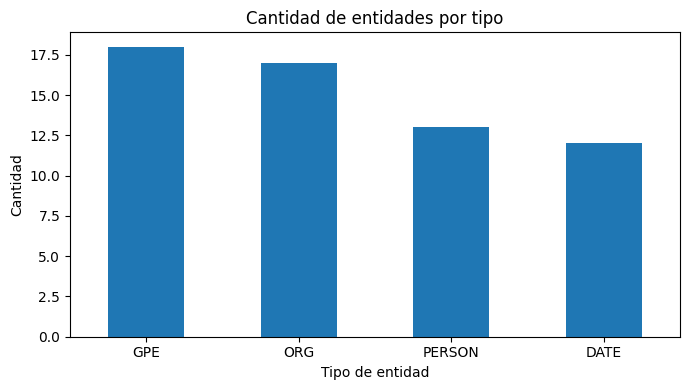

In [7]:
entity_type_counts = (
    entities["entity_type"]
    .value_counts()
    .rename_axis("entity_type")
    .reset_index(name="count")
)

display(entity_type_counts)

ax = entity_type_counts.plot(
    x="entity_type",
    y="count",
    kind="bar",
    legend=False,
    figsize=(7, 4)
)
ax.set_title("Cantidad de entidades por tipo")
ax.set_xlabel("Tipo de entidad")
ax.set_ylabel("Cantidad")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretación:** se espera encontrar las cuatro clases. No tienen que aparecer en cantidades idénticas, porque cada resumen contiene diferente número de personas, organizaciones, lugares y fechas.

In [8]:
expected_types = {"PERSON", "ORG", "GPE", "DATE"}
found_types = set(entities["entity_type"])

assert expected_types.issubset(found_types)
print("VERIFICACIÓN SUPERADA: se encontraron los cuatro tipos esperados.")

VERIFICACIÓN SUPERADA: se encontraron los cuatro tipos esperados.


## 8. Entidades más frecuentes

Se identifican las entidades que aparecen con mayor frecuencia en todo el corpus.

In [9]:
top_entities = (
    entities.groupby(["entity", "entity_type"])
    .size()
    .reset_index(name="frequency")
    .sort_values(["frequency", "entity"], ascending=[False, True])
    .head(15)
)

display(top_entities)

,entity,entity_type,frequency
0,1998,DATE,1
1,2016,DATE,1
2,2018,DATE,1
3,2019,DATE,1
4,2020,DATE,1
5,2021,DATE,1
6,2022,DATE,1
7,2023,DATE,1
8,2024,DATE,1
9,2025,DATE,1


En un corpus pequeño es normal que muchas entidades aparezcan una sola vez. En colecciones reales, esta tabla ayuda a descubrir personas, lugares u organizaciones dominantes.

## 9. Extracción de frases clave con TF-IDF

Una frase clave es una palabra o combinación de palabras que representa bien el contenido de un documento.

Se utiliza TF-IDF para dar mayor importancia a expresiones frecuentes dentro de un resumen, pero poco comunes en el resto del corpus.

In [10]:
# Configura TF-IDF para identificar palabras y frases importantes
# dentro de los resúmenes de las películas.
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",  # Elimina palabras comunes del inglés
    ngram_range=(1, 3),    # Analiza palabras y frases de hasta tres términos
    min_df=1               # Conserva términos que aparezcan al menos una vez
)

# Aprende el vocabulario y calcula la importancia de cada término
# en cada resumen.
tfidf_matrix = tfidf_vectorizer.fit_transform(
    data["clean_plot"]
)

# Recupera las palabras y frases asociadas con las columnas
# de la matriz TF-IDF.
terms = np.array(
    tfidf_vectorizer.get_feature_names_out()
)

print("Forma de la matriz TF-IDF:", tfidf_matrix.shape)

Forma de la matriz TF-IDF: (12, 475)


In [11]:
def extract_key_phrases(matrix, vocabulary, row_index, top_n=5):
    scores = matrix[row_index].toarray().ravel()
    strongest = scores.argsort()[-top_n:][::-1]

    return [
        (vocabulary[index], round(float(scores[index]), 3))
        for index in strongest
        if scores[index] > 0
    ]

key_phrase_rows = []

for index, row in data.iterrows():
    phrases = extract_key_phrases(tfidf_matrix, terms, index, top_n=5)

    for phrase, score in phrases:
        key_phrase_rows.append({
            "movie_id": row["movie_id"],
            "title": row["title"],
            "key_phrase": phrase,
            "score": score
        })

key_phrases = pd.DataFrame(key_phrase_rows)
display(key_phrases.head(15))

,movie_id,title,key_phrase,score
0,1,Mission to Mars,mission houston mars,0.150
1,1,Mission to Mars,crew dangerous solar,0.150
2,1,Mission to Mars,crew dangerous,0.150
3,1,Mission to Mars,crew,0.150
4,1,Mission to Mars,elena,0.150
5,2,The Last Goal,2022 european,0.141
6,2,The Last Goal,2022 european final,0.141
7,2,The Last Goal,winning,0.141
8,2,The Last Goal,winning goal,0.141
9,2,The Last Goal,goal madrid united,0.141


### Interpretación

Para *Mission to Mars* deberían aparecer expresiones relacionadas con `mars`, `spacecraft`, `solar storm` o `nasa`.

El valor `score` indica qué tan representativa es la frase dentro del documento. Un valor mayor implica mayor relevancia relativa.

## 10. N-gramas frecuentes

Un n-grama es una secuencia de palabras:

- unigrama: una palabra;
- bigrama: dos palabras;
- trigrama: tres palabras.

Se analizan bigramas y trigramas para encontrar expresiones frecuentes.

In [12]:
ngram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 3),
    min_df=1
)

ngram_matrix = ngram_vectorizer.fit_transform(data["clean_plot"])
ngram_terms = np.array(ngram_vectorizer.get_feature_names_out())
ngram_counts = np.asarray(ngram_matrix.sum(axis=0)).ravel()

top_ngrams = (
    pd.DataFrame({
        "ngram": ngram_terms,
        "frequency": ngram_counts
    })
    .sort_values(["frequency", "ngram"], ascending=[False, True])
    .head(15)
)

display(top_ngrams)

,ngram,frequency
0,1998 searches,1
1,1998 searches lost,1
2,2018 documents,1
3,2018 documents northern,1
4,2019 team,1
5,2019 team searches,1
6,2020 outbreak,1
7,2020 outbreak collaborates,1
8,2021 olympic,1
9,2021 olympic games,1


## 11. Nube de palabras

La nube de palabras ofrece una visión general del vocabulario. Las palabras de mayor tamaño aparecen con mayor frecuencia.

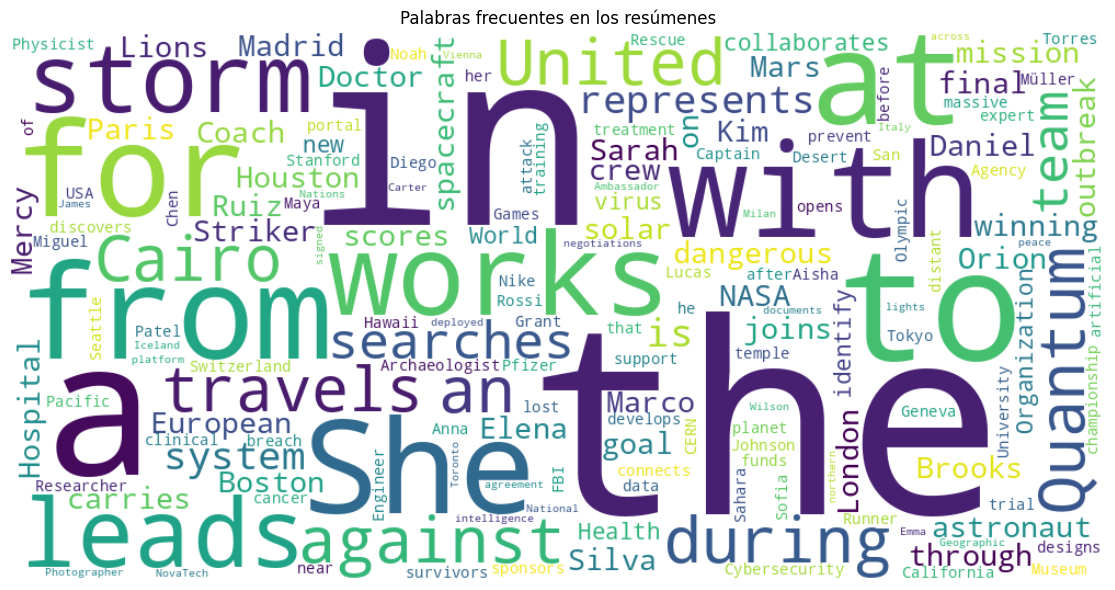

In [13]:
all_text = " ".join(data["clean_plot"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=set(),
    collocations=False,
    random_state=42
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Palabras frecuentes en los resúmenes")
plt.tight_layout()
plt.show()

La nube permite reconocer rápidamente el vocabulario dominante, pero no sustituye las tablas de entidades ni las frases clave porque no conserva el contexto.

## 12. Integración de resultados

Se combina la información de películas con la cantidad de entidades detectadas por resumen.

In [14]:
entity_summary = (
    entities.groupby(["movie_id", "entity_type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

results = data.merge(entity_summary, on="movie_id", how="left")
results = results.fillna(0)

display(
    results[
        ["title", "genre", "word_count", "PERSON", "ORG", "GPE", "DATE"]
    ]
)

,title,genre,word_count,PERSON,ORG,GPE,DATE
0,Mission to Mars,Science Fiction,25,1,1,2,1
1,The Last Goal,Sports,24,2,2,1,1
2,The Silent Virus,Medical Drama,25,1,2,1,1
3,Code Black,Technology,25,1,2,1,1
4,Desert Treasure,Adventure,25,1,1,2,1
5,Ocean Rescue,Adventure,23,1,1,2,1
6,The Quantum Door,Science Fiction,22,1,1,2,1
7,Champions of Tokyo,Sports,20,1,2,1,1
8,The Hidden Cure,Medical Drama,19,1,2,1,1
9,Digital City,Technology,20,1,1,2,1


Esta tabla funciona como una versión local y simplificada de los datos que podrían enviarse a un motor de búsqueda o a un panel de visualización.

## 13. Panel interactivo local

Plotly permite explorar los resultados sin OpenSearch ni Kibana.

In [15]:
genre_summary = (
    results.groupby("genre")[["PERSON", "ORG", "GPE", "DATE"]]
    .sum()
    .reset_index()
)

genre_long = genre_summary.melt(
    id_vars="genre",
    var_name="entity_type",
    value_name="count"
)

fig = px.bar(
    genre_long,
    x="genre",
    y="count",
    color="entity_type",
    barmode="group",
    title="Entidades detectadas por género"
)

fig.show()

### ¿Qué debemos observar?

Cada género presenta una combinación distinta de entidades. Por ejemplo, las películas deportivas suelen incluir equipos, atletas, ciudades y fechas; las tecnológicas incluyen empresas y organizaciones.

## 14. Búsqueda y filtrado

La siguiente función permite encontrar películas que contengan una entidad específica.

In [16]:
def search_movies_by_entity(entity_name):
    matches = entities[
        entities["entity"].str.lower() == entity_name.lower()
    ]

    if matches.empty:
        print("No se encontraron películas con esa entidad.")
        return pd.DataFrame()

    return matches[["title", "genre", "entity", "entity_type"]]

display(search_movies_by_entity("NASA"))
display(search_movies_by_entity("Tokyo"))

,title,genre,entity,entity_type
2,Mission to Mars,Science Fiction,NASA,ORG


,title,genre,entity,entity_type
39,Champions of Tokyo,Sports,Tokyo,GPE


## 15. Validación controlada

Se comprueba que algunas entidades conocidas hayan sido identificadas correctamente.

In [17]:
expected_entities = {
    ("Elena Ruiz", "PERSON"),
    ("NASA", "ORG"),
    ("Houston", "GPE"),
    ("2045", "DATE"),
    ("World Health Organization", "ORG"),
    ("Tokyo", "GPE")
}

detected_entities = set(
    zip(entities["entity"], entities["entity_type"])
)

missing = expected_entities - detected_entities

if not missing:
    print("RESULTADO ESPERADO: todas las entidades de control fueron detectadas.")
else:
    print("RESULTADO DUDOSO. Faltan:", missing)

assert not missing

RESULTADO ESPERADO: todas las entidades de control fueron detectadas.


## 16. Actividades para estudiantes

1. Agregue tres nuevas películas al conjunto de datos.
2. Incorpore nuevas personas, organizaciones y lugares al `EntityRuler`.
3. Compare los resultados antes y después de agregar los patrones.
4. Examine las cinco frases clave de cada nueva película.
5. Busque los bigramas más frecuentes.
6. Filtre las películas que contienen una organización específica.
7. Explique la diferencia entre una entidad, una palabra frecuente y una frase clave.
8. Proponga una limitación del enfoque basado en reglas.

## 17. Conclusiones

En este laboratorio se construyó un flujo local completo para:

1. explorar y normalizar resúmenes de películas;
2. reconocer personas, organizaciones, lugares y fechas;
3. extraer frases clave mediante TF-IDF;
4. analizar n-gramas;
5. generar una nube de palabras;
6. integrar los resultados en tablas;
7. visualizar y filtrar la información;
8. verificar automáticamente que las entidades esperadas fueron detectadas.

La actividad conserva el objetivo del laboratorio original, pero utiliza herramientas generales de Python y puede ejecutarse completamente de forma local.